**Autora**: Suny Brunoldi

**Información utilizada:** [Banco Central](https://datos.gob.do/dataset/serie-historica-dolar_)

# **Evolución del precio del dólar (1985-2021)**

El tipo de cambio constituye una variable fundamental para la planificación financiera, la valoración de obligaciones en moneda extranjera y el análisis de riesgos en economías abiertas. Este proyecto examina la evolución histórica de las tasas de compra y venta del dólar estadounidense en la República Dominicana entre 1985 y 2021, utilizando información de referencia del Banco Central.

El estudio combina análisis exploratorio, medición de variaciones, estimación del spread cambiario, evaluación de dispersión y construcción de un modelo base de proyección. El propósito es identificar patrones relevantes, periodos de mayor inestabilidad y posibles implicaciones para la toma de decisiones financieras.

# **Objetivo**

*   Analizar la evolución histórica del tipo de cambio de referencia en la República Dominicana, identificando tendencias, variaciones, características relevantes y más para la gestión financiera.

In [ ]:
# Importación del archivo
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Lectura y visualización de datos
import pandas as pd
df_dolar = pd.read_csv("/content/drive/MyDrive/Portafolio_data/Predicción_del_dólar/TASA_DOLAR_REFERENCIA_TD_20210903.csv")
df_dolar.head()

,Año,Mes,Compra,Venta
0,1985,Ene,3.26,3.28
1,1985,Feb,3.26,3.28
2,1985,Mar,3.31,3.33
3,1985,Abr,3.21,3.24
4,1985,May,3.17,3.20


In [ ]:
df_dolar.tail()

,Año,Mes,Compra,Venta
435,2021,Abr,56.7968,57.0965
436,2021,May,56.7919,57.0402
437,2021,Jun,56.8786,57.1258
438,2021,Jul,56.9621,57.1956
439,2021,Ago,56.9299,57.1854


# **Variables**

* Año: año correspondiente a la observación.

* Mes: mes en el que fue registrada la tasa.

* Compra: valor de referencia utilizado para la compra del dólar.

* Venta: valor de referencia utilizado para la venta del dólar.



# **Análisis exploratorio de la calidad de los datos (EDA)**


*   Análisis de valores nulos y duplicados.
*   Corrección de palabras mal escritas.
*   Mapeo de meses.



In [ ]:
# Búsqueda de datos nulos
df_dolar.isnull().sum()
print(f"La cantidad de valores nulos es: {df_dolar.isnull().sum()}")

La cantidad de valores nulos es: Año       0
Mes       0
Compra    0
Venta     0
dtype: int64


In [ ]:
# Búsqueda de datos duplicados
df_dolar.duplicated().sum()
print(f"La cantidad de valores duplicados es: {df_dolar.duplicated().sum()}")

La cantidad de valores duplicados es: 0


In [ ]:
# Corrección de palabras mal escritas
df_dolar["Mes"].unique()

array(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep',
       'Oct', 'Nov', 'Dic', 'Aug'], dtype=object)

In [ ]:
df_dolar["Mes"] = df_dolar["Mes"].replace({
    "Aug": "Ago"
})

In [ ]:
# Mapeo y organización de meses
data = df_dolar.copy()
mapa_meses = {
    "Ene": 1, "Feb": 2, "Mar": 3, "Abr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Ago": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dic": 12
}
data["Mes_num"] = data["Mes"].map(mapa_meses)

data["Fecha"] = pd.to_datetime(
    dict(
        year=data["Año"],
        month=data["Mes_num"],
        day=1
    )
)
data = data.sort_values("Fecha")


# **Porcentaje de crecimiento**

In [ ]:
# Evaluación porcentual del crecimiento histórico en la compra & venta del dólar
valor_inicial = 3.2600
valor_final = 56.9299
diferencia = ((valor_final - valor_inicial) / valor_inicial) * 100
print(f"El aumento del valor del dólar en la compra es de:{diferencia: .2f}%")

valor_inicial = 3.2800
valor_final = 57.1854
diferencia = ((valor_final - valor_inicial) / valor_inicial) * 100
print(f"El aumento del valor del dólar en la venta es de:{diferencia: .2f}%")

El aumento del valor del dólar en la compra es de: 1646.32%
El aumento del valor del dólar en la venta es de: 1643.46%


La diferencia porcentual evaluada es de más del 1600%, por lo que, estudiar los acontecimientos ocurridos entre esos 30 años, nos dan una vista más profunda de las razones detrás del comportamiento de la tasa del dólar.

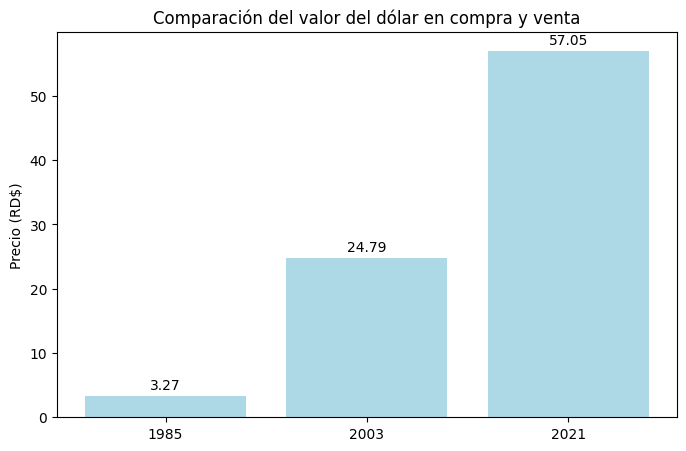

In [ ]:
import matplotlib.pyplot as plt

# Gráfico 1: Precio del dólar en 3 tiempos seleccionados
años = ['1985', "2003", '2021']
valores = [3.27, 24.79, 57.05] # Promedio de la compra y venta máxima, miníma y mediana

plt.figure(figsize=(8,5))
plt.bar(años, valores, color=['lightblue', 'lightblue'])

plt.title("Comparación del valor del dólar en compra y venta")
plt.ylabel("Precio (RD$)")

for i, v in enumerate(valores):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.show()

Este gráfico muestra el comportamiento del dólar dentro de los años propuestos. La tasa del dólar siguió una tendencia alcista y el peso dominicano sufrió una depreciación. Todos estos años simplemente reflejan un crecimiento no uniforme, pero al mismo tiempo una trayecto gradual.

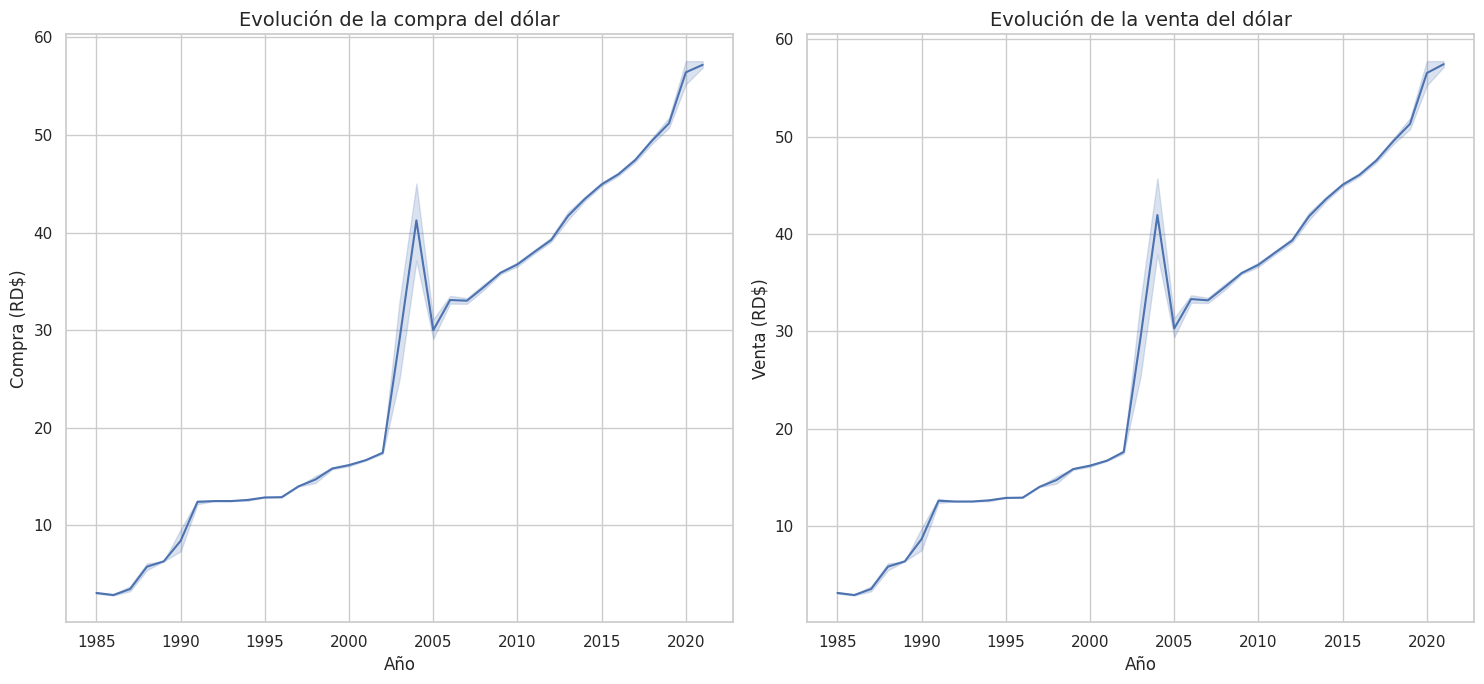

In [ ]:
# Evolución del precio de la compra y venta del dólar de manera histórica
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(15,7))  # 1 fila, 2 columnas

# Gráfico #1: Compra
sns.lineplot(
    data=df_dolar,
    x="Año",
    y="Compra",
    estimator="mean",
    ax=ax[0]
)

ax[0].set_title("Evolución de la compra del dólar", fontsize=14)
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Compra (RD$)")

# Gráfico #2: Venta
sns.lineplot(
    data=df_dolar,
    x="Año",
    y="Venta",
    estimator="mean",
    ax=ax[1]
)

ax[1].set_title("Evolución de la venta del dólar", fontsize=14)
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Venta (RD$)")

plt.tight_layout()
plt.show()

**Evolución de la compra y venta del dólar**

La serie evidencia una alteración significativa alrededor del episodio de inestabilidad bancaria iniciado en 2003. Durante este periodo se produjeron presiones monetarias y fiscales asociadas a la asistencia de liquidez y a las medidas de estabilización implementadas por las autoridades.

No obstante, la trayectoria no fue estrictamente ascendente. El tipo de cambio alcanzó niveles elevados a comienzos de 2004 y posteriormente registró una corrección durante el resto de ese año y en 2005. Este comportamiento demuestra la importancia de distinguir entre tendencias estructurales de largo plazo y fluctuaciones coyunturales derivadas de episodios de estrés.

[Información de referencia](https://www.imf.org/en/news/articles/2015/09/28/04/53/pn03123)

# **Tasa anual del crecimiento compuesto (CAGR)**

In [ ]:
valor_inicial_compra = 3.2600
valor_final_compra = 56.9299

años = 2021 - 1985
cagr_compra = (
(valor_final_compra / valor_inicial_compra) ** (1 / años)) - 1
print(f"CAGR de compra: {cagr_compra:.2%}")

valor_inicial_venta = 3.2800
valor_final_venta = 57.1854
cagr_venta = (
(valor_final_venta / valor_inicial_venta) ** (1 / años)) - 1
print(f"CAGR de venta: {cagr_venta:.2%}")


CAGR de compra: 8.27%
CAGR de venta: 8.26%


# **Volatilidad**

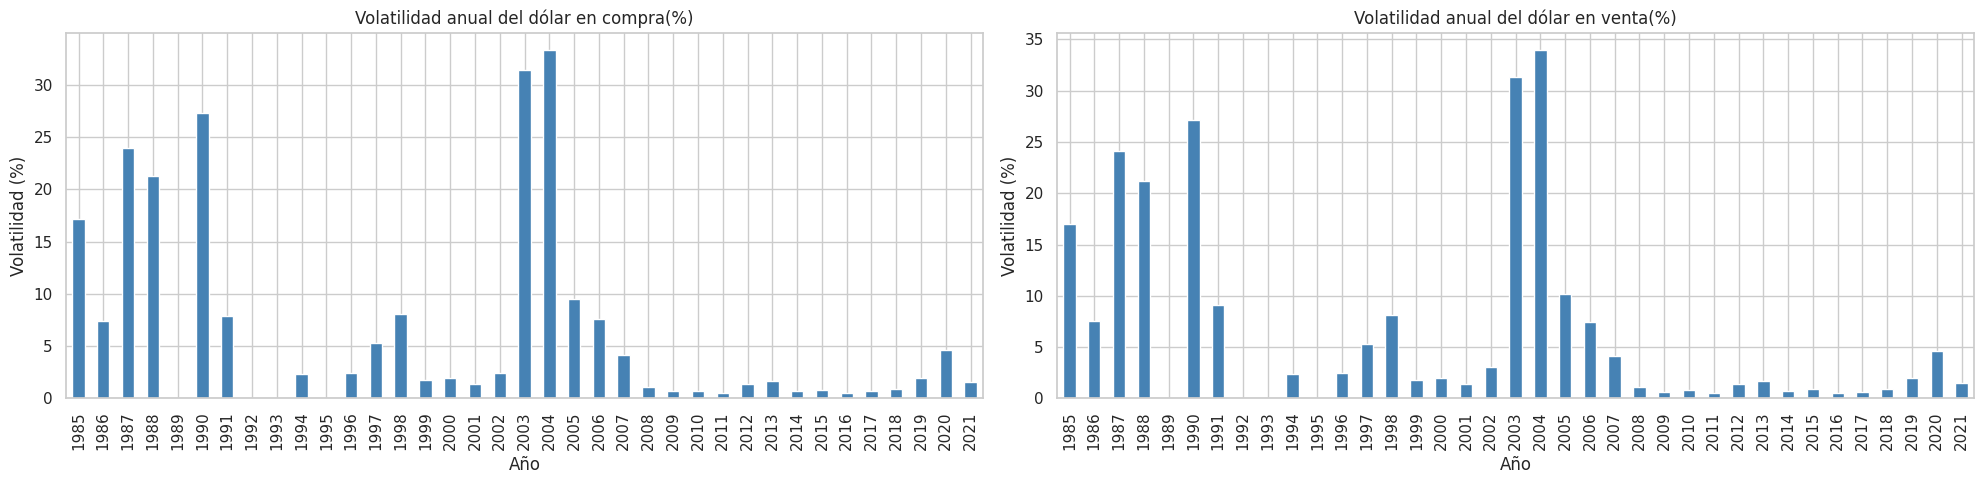

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
data["Retorno_log_compra"] = np.log(
    data["Compra"] / data["Compra"].shift(1)
)
data["Retorno_log_venta"] = np.log(
    data["Venta"] / data["Venta"].shift(1)
)
volatilidad_anual_compra = (
    data.groupby("Año")["Retorno_log_compra"].std()
    * np.sqrt(12)
    * 100
)
volatilidad_anual_venta = (
    data.groupby("Año")["Retorno_log_venta"].std()
    * np.sqrt(12)
    * 100
)
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Gráfico de compra
volatilidad_anual_compra.plot(
    kind="bar",
    color="steelblue",
    ax=ax[0]
)
ax[0].set_title("Volatilidad anual del dólar en compra(%)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Volatilidad (%)")

# Gráfico de venta
volatilidad_anual_venta.plot(
    kind="bar",
    color="steelblue",
    ax=ax[1]
)
ax[1].set_title("Volatilidad anual del dólar en venta(%)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Volatilidad (%)")
plt.tight_layout()
plt.show()

En la década de los 80, el mercado cambiario experimentó una volatilidad de más del 20%, así que existía mucha incertidumbre sobre el comportamiento del peso.(En 1989 es donde varía, la volatilidad fue de 0).

En la década de los 2000, especialmente entre el 2003-2004, la volatilidad superó el 30%, lo que significa que fue el periodo más inestable dentro del intervalo de tiempo analizado. Esto está asociado a la crisis bancaria del aquel momento.

En años posteriores, la volatilidad tuvo una reducción drástica, esto quiere decir que la moneda posee mayor estabilidad y menos incertidumbre cambiaria.

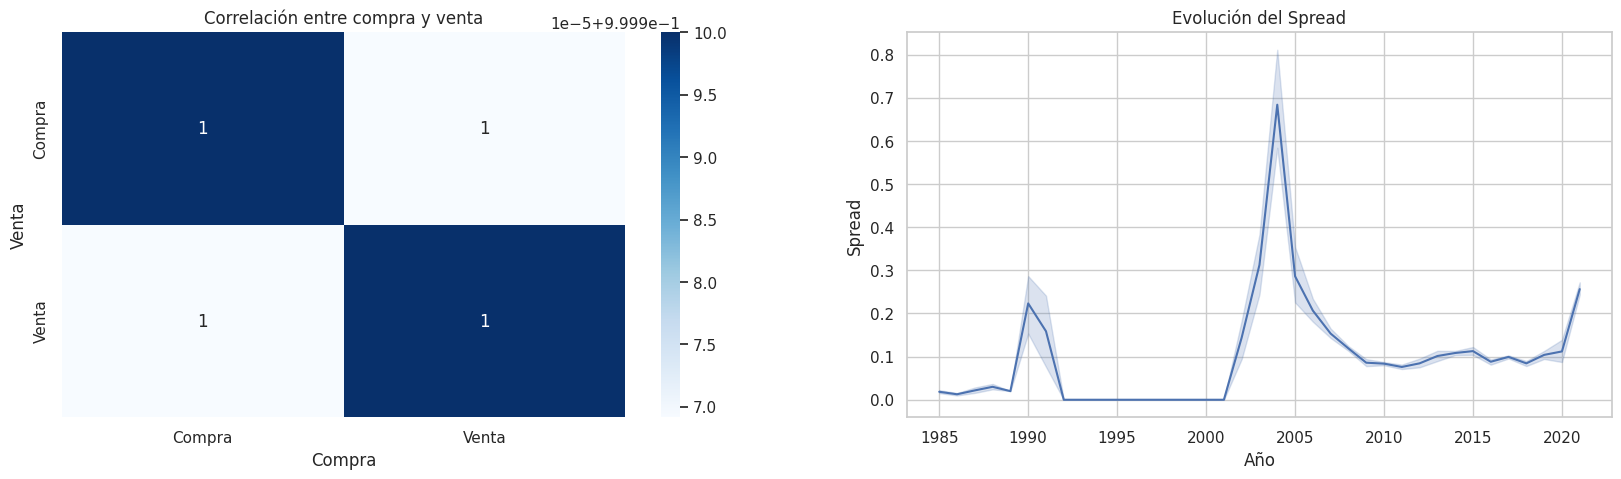

In [ ]:
# Spread cambiario
df_dolar["Spread"] = df_dolar["Venta"] - df_dolar["Compra"]
corr = df_dolar[["Compra", "Venta"]].corr()
df_dolar["Spread_pct"] = (
    (df_dolar["Venta"] - df_dolar["Compra"])
    / df_dolar["Compra"]
) * 100

import seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Gráfico de correlación
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Correlación entre compra y venta")
ax[0].set_xlabel("Compra")
ax[0].set_ylabel("Venta")

# Gráfico de la evolución del spread
sns.lineplot(
    data=df_dolar,
    x="Año",
    y="Spread",
    ax=ax[1]
)
ax[1].set_title("Evolución del Spread")
ax[1].set_xlabel("Año")

plt.show()



El primer gráfico presenta la correlación que existe entre la compra y venta. La correlación indica que: cuando aumenta la tasa compra, aumenta la de venta y viceversa. Esto es esperable, ya que ambas tasas pertenecen al mismo mercado.

El segundo gráfico muestra las condiciones de intermediación. En los primeros 15 años, el spread era relativamente bajo y el mercado operaba con márgenes relativamente reducidos.

Después del 2003, ocurrió una explosión del spread, el cual coincide con los años de mayor volatilidad.

A partir del 2005 hasta la fecha actual, el spread alcanza una normalización gradual.

In [ ]:
df_dolar["Spread_pct"] = (
    (df_dolar["Venta"] - df_dolar["Compra"])
    / df_dolar["Compra"]
) * 100
print(f"El porcentaje de spread es de: {df_dolar['Spread_pct'].mean():.2f}%")

El porcentaje de spread es de: 0.41%


El análisis del spread cambiario evidencia que la diferencia promedio porcentual entre las tasas de compra y venta del dólar fue de aproximadamente 0.41%. Este resultado sugiere que el mercado cambiario dominicano mantuvo niveles relativamente bajos de dispersión entre ambas tasas, reflejando condiciones de liquidez adecuadas y una estructura de intermediación eficiente, incluso después de haber sufrido una crisis.

# **Factores que afectan a la conducta del dólar**

El comportamiento del tipo de cambio responde a la interacción entre la oferta y la demanda de divisas. Desde el lado de la demanda, las importaciones, el servicio de obligaciones en moneda extranjera y los requerimientos de cobertura pueden generar presiones alcistas. Desde el lado de la oferta, las remesas, los ingresos por turismo, las exportaciones y los flujos de capital incrementan la disponibilidad de divisas.

La inflación y las condiciones monetarias también pueden influir en la trayectoria cambiaria. Una inflación doméstica persistentemente superior a la externa puede reducir el poder adquisitivo relativo de la moneda local, mientras que las decisiones de política monetaria afectan el costo del dinero y los incentivos de los participantes del mercado. Asimismo, los precios internacionales del petróleo pueden incidir sobre la demanda de divisas mediante la factura de importación energética.

[Información de referencia](https://dolar.do/blog/que-factores-mueven-tasa-dolar-republica-dominicana)











# **Modelo predictivo para evaluar el comportamiento futuro del valor del dólar**

CALIDAD DE DATOS
  Corrección: fila 12: 1985-01 duplicada -> reasignada a 1986-01
  Registros: 440 | Rango: 1985-01 a 2021-08
  Meses faltantes: 0 []
  Venta < Compra en 0 meses

WALK-FORWARD (ventana expansiva, sin ver el futuro)
  Orígenes evaluados: 35 | Período: 2013-02 a 2021-08

MAPE por horizonte:
                  MAPE h=1m (%)  MAPE h=3m (%)  MAPE h=6m (%)  MAPE h=12m (%)  MAPE promedio (%)
Modelo                                                                                          
Naive                     0.338          1.142          2.272           4.244              1.999
Drift                     0.290          0.793          1.419           1.873              1.094
Regresión lineal          1.720          1.836          1.985           2.187              1.932
Holt                      0.311          0.947          1.665           2.348              1.318
Holt-Winters              0.363          1.223          1.930           2.502              1.504
SARIMA         

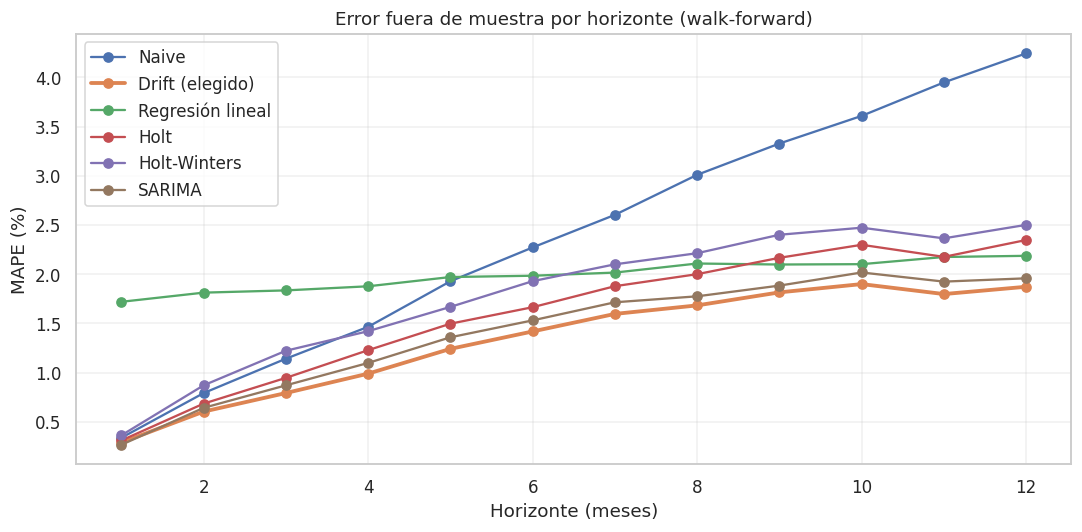

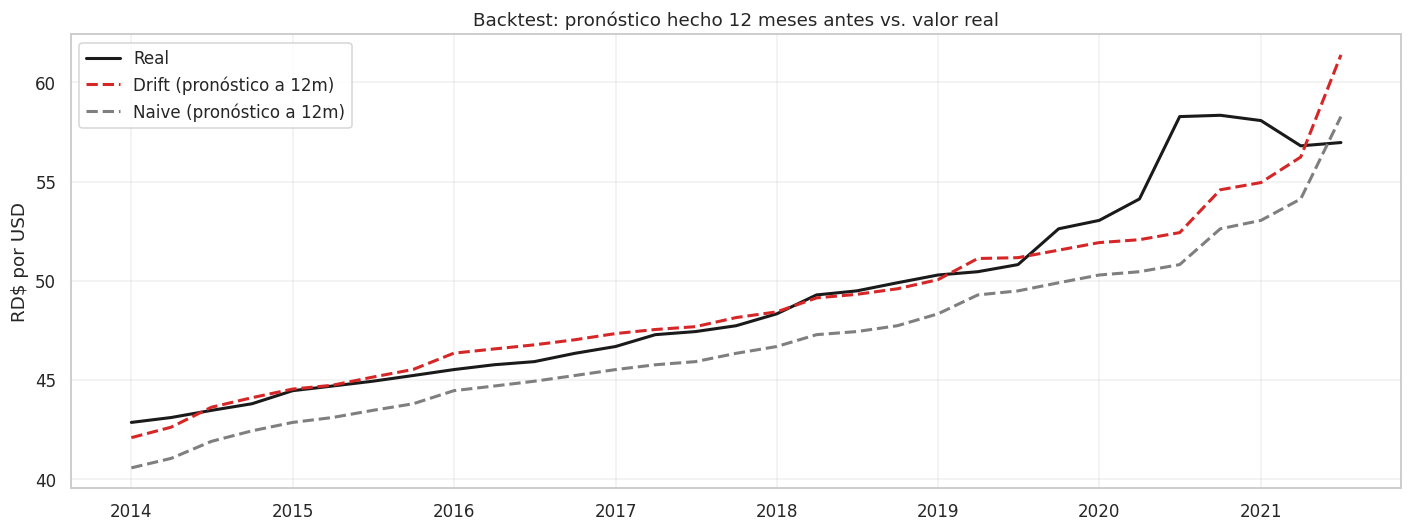

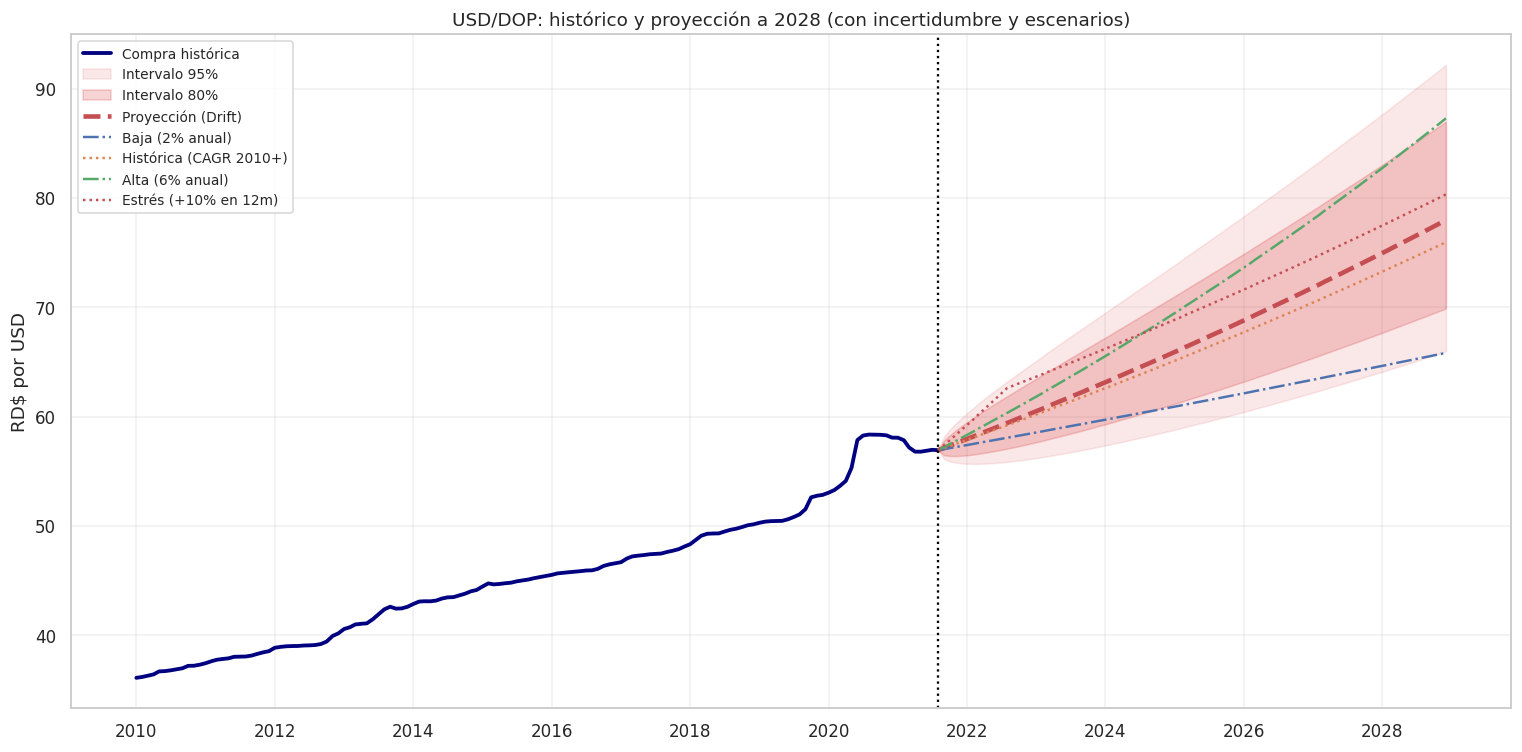


Archivos guardados: proyeccion_usd_dop.csv, metricas_walk_forward.csv, escenarios_usd_dop.csv


In [43]:
# ============================================================
# PRONÓSTICO USD/DOP — VERSIÓN PROFESIONAL
# Limpieza robusta + walk-forward + intervalos + escenarios
# Listo para pegar en Google Colab (una sola celda)
# ============================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ============================================================
# 0. CONFIGURACIÓN (lo único que normalmente tocarás)
# ============================================================

CSV_PATH = "TASA_DOLAR_REFERENCIA_TD_20210903.csv"

TRAIN_START = "2006-01-01"   # régimen actual: excluye tasa administrada y crisis 2003-04
FECHA_FINAL = "2028-12-01"   # fin de la proyección

FIRST_ORIGIN = "2013-01-01"  # primer punto de corte del walk-forward
ORIGIN_STEP = 3              # re-entrenar cada N meses (1 = más lento, más preciso)
MAX_H = 12                   # horizonte máximo evaluado (meses)
HORIZONS_EVAL = (1, 3, 6, 12)

DRIFT_WINDOW = 60            # meses usados para estimar la depreciación media
TREND_WINDOW = 120           # ventana (meses) de la regresión lineal sobre log(precio)
SPREAD_WINDOW = 12           # meses para estimar el spread Venta/Compra

# Escenarios de depreciación anual desde el último dato real
ESCENARIOS = {
    "Baja (2% anual)": 0.02,
    "Histórica (CAGR 2010+)": None,   # se calcula con los datos
    "Alta (6% anual)": 0.06,
}
SHOCK_ESTRES = 0.10          # salto de +10% en 12 meses (tipo 2020), luego ritmo histórico

# ============================================================
# 1. CARGA Y LIMPIEZA DE DATOS
# ============================================================

MAPA_MESES = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "aug": 8, "sep": 9, "set": 9, "oct": 10,
    "nov": 11, "dic": 12, "dec": 12, "jan": 1, "apr": 4,
}

try:
    raw = df_dolar.copy()                                   # noqa: F821 (existe en tu notebook)
except NameError:
    raw = pd.read_csv(CSV_PATH, encoding="utf-8-sig")

raw.columns = raw.columns.str.strip()

mes_txt = raw["Mes"].astype(str).str.strip().str.lower().str[:3]
raw["Mes"] = pd.to_numeric(raw["Mes"], errors="coerce").fillna(mes_txt.map(MAPA_MESES))
for col in ["Año", "Compra", "Venta"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw = raw.dropna(subset=["Año", "Mes", "Compra", "Venta"]).reset_index(drop=True)
raw["Año"] = raw["Año"].astype(int)
raw["Mes"] = raw["Mes"].astype(int)

# --- Corrección de fechas duplicadas -------------------------------------
# El archivo es secuencial (un registro por mes). Si una fecha aparece repetida,
# se reasigna al mes que corresponde según el orden del archivo.
fechas, vistos, avisos = [], set(), []
for i, fila in raw.iterrows():
    f = pd.Timestamp(year=int(fila["Año"]), month=int(fila["Mes"]), day=1)
    if f in vistos and fechas:
        esperada = fechas[-1] + pd.DateOffset(months=1)
        avisos.append(f"fila {i}: {f:%Y-%m} duplicada -> reasignada a {esperada:%Y-%m}")
        f = esperada
    vistos.add(f)
    fechas.append(f)
raw["Fecha"] = fechas

data = raw.sort_values("Fecha").set_index("Fecha")[["Compra", "Venta"]].copy()
data.index.freq = None

# --- Validaciones ---------------------------------------------------------
rango = pd.date_range(data.index.min(), data.index.max(), freq="MS")
faltantes = rango.difference(data.index)
assert data.index.is_unique, "Aún hay fechas duplicadas"

print("=" * 60)
print("CALIDAD DE DATOS")
print("=" * 60)
for a in avisos:
    print("  Corrección:", a)
print(f"  Registros: {len(data)} | Rango: {data.index.min():%Y-%m} a {data.index.max():%Y-%m}")
print(f"  Meses faltantes: {len(faltantes)}", [f"{x:%Y-%m}" for x in faltantes])
print(f"  Venta < Compra en {(data['Venta'] < data['Compra']).sum()} meses")

data = data.reindex(rango).interpolate()   # por si faltara algún mes
data.index.freq = "MS"
data["Spread_pct"] = data["Venta"] / data["Compra"] - 1

ultima_fecha = data.index.max()
ultimo_compra = data["Compra"].iloc[-1]

# Serie de trabajo: log(Compra) en el régimen actual
y_log = np.log(data["Compra"].loc[TRAIN_START:])
y_log.index.freq = "MS"

# ============================================================
# 2. MODELOS (todos trabajan sobre log-precio y parten del último dato)
# ============================================================

def pronosticar(train_log: pd.Series, h: int) -> dict:
    """Devuelve {modelo: pronóstico en log-nivel} para h meses adelante."""
    pasos = np.arange(1, h + 1)
    ultimo = train_log.iloc[-1]
    out = {}

    # Naive: el valor de hoy es el de mañana (benchmark obligatorio)
    out["Naive"] = np.repeat(ultimo, h)

    # Drift: último valor + depreciación media reciente
    r = train_log.diff().dropna().iloc[-DRIFT_WINDOW:]
    out["Drift"] = ultimo + r.mean() * pasos

    # Regresión lineal sobre log(precio), ventana móvil (versión corregida de tu modelo)
    w = train_log.iloc[-TREND_WINDOW:]
    t = np.arange(len(w))
    coef = np.polyfit(t, w.values, 1)
    out["Regresión lineal"] = np.polyval(coef, np.arange(len(w), len(w) + h))

    # Holt (tendencia aditiva) y Holt-Winters (con estacionalidad)
    try:
        m = ExponentialSmoothing(train_log, trend="add", seasonal=None,
                                 initialization_method="estimated").fit()
        out["Holt"] = m.forecast(h).values
    except Exception:
        out["Holt"] = out["Drift"]
    try:
        m = ExponentialSmoothing(train_log, trend="add", seasonal="add", seasonal_periods=12,
                                 initialization_method="estimated").fit()
        out["Holt-Winters"] = m.forecast(h).values
    except Exception:
        out["Holt-Winters"] = out["Drift"]

    # SARIMA(1,1,1)(1,0,0,12) con deriva
    try:
        m = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 0, 0, 12),
                    trend="c").fit(disp=False, maxiter=200)
        out["SARIMA"] = m.forecast(h).values
    except Exception:
        out["SARIMA"] = out["Drift"]

    return out


MODELOS = ["Naive", "Drift", "Regresión lineal", "Holt", "Holt-Winters", "SARIMA"]
CANDIDATOS = [m for m in MODELOS if m != "Naive"]   # Naive es solo benchmark (es plano)

# ============================================================
# 3. WALK-FORWARD VALIDATION (out-of-sample real)
# ============================================================

print("\n" + "=" * 60)
print("WALK-FORWARD (ventana expansiva, sin ver el futuro)")
print("=" * 60)

n = len(y_log)
i0 = y_log.index.get_loc(pd.Timestamp(FIRST_ORIGIN))
registros = []

for i in range(i0, n - 1, ORIGIN_STEP):
    train = y_log.iloc[: i + 1]
    h = min(MAX_H, n - 1 - i)
    preds = pronosticar(train, h)
    for modelo, p in preds.items():
        for k in range(h):
            registros.append({
                "Origen": y_log.index[i],
                "Fecha": y_log.index[i + 1 + k],
                "h": k + 1,
                "Modelo": modelo,
                "Real": np.exp(y_log.iloc[i + 1 + k]),
                "Pred": np.exp(p[k]),
                "Err_log": y_log.iloc[i + 1 + k] - p[k],
            })

bt = pd.DataFrame(registros)
bt["Err"] = bt["Real"] - bt["Pred"]
bt["APE"] = bt["Err"].abs() / bt["Real"] * 100

print(f"  Orígenes evaluados: {bt['Origen'].nunique()} | "
      f"Período: {bt['Fecha'].min():%Y-%m} a {bt['Fecha'].max():%Y-%m}")

met = (bt.groupby(["Modelo", "h"])
         .agg(MAE=("Err", lambda s: s.abs().mean()),
              RMSE=("Err", lambda s: np.sqrt((s ** 2).mean())),
              MAPE=("APE", "mean"))
         .reset_index())

naive_mae = met[met["Modelo"] == "Naive"].set_index("h")["MAE"]
met["MAE_vs_Naive"] = met.apply(lambda r: r["MAE"] / naive_mae[r["h"]], axis=1)

tabla_mape = (met[met["h"].isin(HORIZONS_EVAL)]
              .pivot(index="Modelo", columns="h", values="MAPE")
              .reindex(MODELOS))
tabla_mape.columns = [f"MAPE h={h}m (%)" for h in tabla_mape.columns]
tabla_mape["MAPE promedio (%)"] = tabla_mape.mean(axis=1)

tabla_mae = (met[met["h"].isin(HORIZONS_EVAL)]
             .pivot(index="Modelo", columns="h", values="MAE")
             .reindex(MODELOS))
tabla_mae.columns = [f"MAE h={h}m (RD$)" for h in tabla_mae.columns]

tabla_skill = (met[met["h"].isin(HORIZONS_EVAL)]
               .pivot(index="Modelo", columns="h", values="MAE_vs_Naive")
               .reindex(MODELOS))
tabla_skill.columns = [f"MAE/Naive h={h}m" for h in tabla_skill.columns]

print("\nMAPE por horizonte:")
print(tabla_mape.round(3).to_string())
print("\nMAE por horizonte (pesos):")
print(tabla_mae.round(3).to_string())
print("\nMAE relativo al Naive (<1 = mejor que Naive):")
print(tabla_skill.round(2).to_string())

mejor = tabla_mape.loc[CANDIDATOS, "MAPE promedio (%)"].idxmin()
print(f"\n>>> Mejor modelo con tendencia (menor MAPE promedio): {mejor}")

# ============================================================
# 4. INCERTIDUMBRE: error empírico del mejor modelo
#    sigma(h) = k * sqrt(h), calibrado con los errores del walk-forward
# ============================================================

e = bt[bt["Modelo"] == mejor]
sigma_h = e.groupby("h")["Err_log"].std()
hs = sigma_h.index.values.astype(float)
k_sigma = float(np.sum(sigma_h.values * np.sqrt(hs)) / np.sum(hs))

Z = {80: 1.2816, 95: 1.9600}

def banda_log(h_arr, nivel):
    return Z[nivel] * k_sigma * np.sqrt(h_arr)

# Calibración: ¿qué % de los reales cae dentro de la banda?
e = e.assign(dentro80=lambda d: d["Err_log"].abs() <= banda_log(d["h"].values, 80),
             dentro95=lambda d: d["Err_log"].abs() <= banda_log(d["h"].values, 95))
print(f"Cobertura en backtest -> banda 80%: {e['dentro80'].mean():.0%} | "
      f"banda 95%: {e['dentro95'].mean():.0%}")

# ============================================================
# 5. PROYECCIÓN FINAL HASTA 2028 (modelo reentrenado con todo el régimen)
# ============================================================

fechas_fut = pd.date_range(ultima_fecha + pd.DateOffset(months=1), FECHA_FINAL, freq="MS")
H = len(fechas_fut)
pasos = np.arange(1, H + 1)

central_log = pronosticar(y_log, H)[mejor]

res = pd.DataFrame({"Fecha": fechas_fut})
res["Año"] = res["Fecha"].dt.year
res["Mes"] = res["Fecha"].dt.month
res["Compra_proyectada"] = np.exp(central_log)
for nivel in (80, 95):
    b = banda_log(pasos, nivel)
    res[f"Compra_inf{nivel}"] = np.exp(central_log - b)
    res[f"Compra_sup{nivel}"] = np.exp(central_log + b)

# Venta = Compra * (1 + spread típico reciente)
spread_tipico = data["Spread_pct"].iloc[-SPREAD_WINDOW:].median()
res["Venta_proyectada"] = res["Compra_proyectada"] * (1 + spread_tipico)
print(f"\nSpread Venta/Compra usado (mediana {SPREAD_WINDOW}m): {spread_tipico:.3%}")

# ============================================================
# 6. ESCENARIOS (para planificación de negocio)
# ============================================================

cagr_2010 = (data["Compra"].iloc[-1] / data["Compra"].loc["2010-01-01"]) ** (
    12 / (len(data.loc["2010-01-01":]) - 1)) - 1
tasas = {k: (cagr_2010 if v is None else v) for k, v in ESCENARIOS.items()}

esc = pd.DataFrame({"Fecha": fechas_fut})
for nombre, tasa in tasas.items():
    esc[nombre] = ultimo_compra * (1 + tasa) ** (pasos / 12)

# Estrés: +SHOCK en 12 meses y luego ritmo histórico
shock = np.where(pasos <= 12, (1 + SHOCK_ESTRES) ** (pasos / 12), 1 + SHOCK_ESTRES)
cola = np.where(pasos > 12, (1 + cagr_2010) ** ((pasos - 12) / 12), 1.0)
esc[f"Estrés (+{SHOCK_ESTRES:.0%} en 12m)"] = ultimo_compra * shock * cola
esc["Modelo (central)"] = res["Compra_proyectada"].values
esc = esc.set_index("Fecha")

# ============================================================
# 7. TABLAS DE RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print(f"PROYECCIÓN HASTA {FECHA_FINAL[:4]}  |  modelo: {mejor}")
print("=" * 60)
print(f"Último dato real ({ultima_fecha:%Y-%m}): Compra = {ultimo_compra:.2f}")
cols_tabla = ["Fecha", "Año", "Mes", "Compra_proyectada", "Compra_inf80", "Compra_sup80",
              "Compra_inf95", "Compra_sup95", "Venta_proyectada"]
resultado_final = res[cols_tabla]
print(resultado_final.tail(24).round(2).to_string(index=False))

anual = (res.groupby("Año")
            .agg(Compra_fin_de_año=("Compra_proyectada", "last"),
                 Inf80=("Compra_inf80", "last"), Sup80=("Compra_sup80", "last"),
                 Inf95=("Compra_inf95", "last"), Sup95=("Compra_sup95", "last")))
niveles = pd.concat([pd.Series({ultima_fecha.year: ultimo_compra}), anual["Compra_fin_de_año"]])
anual["Var_anual_%"] = niveles.pct_change().iloc[1:] * 100
anual.iloc[0, anual.columns.get_loc("Var_anual_%")] = np.nan   # primer año es parcial
print(f"\nRESUMEN ANUAL (fin de año; {ultima_fecha.year} es parcial; Inf/Sup = intervalos de predicción):")
print(anual.round(2).to_string())

print("\nESCENARIOS al final de la proyección:")
fin = esc.iloc[-1].rename("Compra dic-" + FECHA_FINAL[:4]).to_frame()
fin["Var. vs hoy (%)"] = (fin.iloc[:, 0] / ultimo_compra - 1) * 100
print(fin.round(2).to_string())
print(f"\nCAGR 2010-{ultima_fecha.year} usado como depreciación histórica: {cagr_2010:.2%}")

# ============================================================
# 8. GRÁFICOS
# ============================================================

# 8.1 Comparación de modelos por horizonte
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODELOS:
    d = met[met["Modelo"] == m]
    ax.plot(d["h"], d["MAPE"], marker="o", lw=2.5 if m == mejor else 1.5,
            label=m + (" (elegido)" if m == mejor else ""))
ax.set_title("Error fuera de muestra por horizonte (walk-forward)")
ax.set_xlabel("Horizonte (meses)")
ax.set_ylabel("MAPE (%)")
ax.legend()
plt.tight_layout()
plt.show()

# 8.2 Backtest a 12 meses: real vs predicción (mejor modelo y Naive)
fig, ax = plt.subplots(figsize=(13, 5))
b12 = bt[bt["h"] == min(12, MAX_H)]
real12 = b12[b12["Modelo"] == mejor].set_index("Fecha")["Real"]
ax.plot(real12.index, real12.values, "k-", lw=2, label="Real")
for m, c in [(mejor, "tab:red"), ("Naive", "tab:gray")]:
    s = b12[b12["Modelo"] == m].set_index("Fecha")["Pred"]
    ax.plot(s.index, s.values, "--", color=c, lw=2, label=f"{m} (pronóstico a 12m)")
ax.set_title("Backtest: pronóstico hecho 12 meses antes vs. valor real")
ax.set_ylabel("RD$ por USD")
ax.legend()
plt.tight_layout()
plt.show()

# 8.3 Proyección con bandas y escenarios
fig, ax = plt.subplots(figsize=(14, 7))
hist = data["Compra"].loc["2010-01-01":]
ax.plot(hist.index, hist.values, color="navy", lw=2.5, label="Compra histórica")

# La proyección se conecta con el último dato real (sin saltos)
x_fut = [ultima_fecha] + list(fechas_fut)
def conectar(v):
    return np.concatenate([[ultimo_compra], np.asarray(v)])

ax.fill_between(x_fut, conectar(res["Compra_inf95"]), conectar(res["Compra_sup95"]),
                color="tab:red", alpha=0.10, label="Intervalo 95%")
ax.fill_between(x_fut, conectar(res["Compra_inf80"]), conectar(res["Compra_sup80"]),
                color="tab:red", alpha=0.20, label="Intervalo 80%")
ax.plot(x_fut, conectar(res["Compra_proyectada"]), "r--", lw=3, label=f"Proyección ({mejor})")

estilos = ["-.", ":", "-.", ":"]
for (col, est) in zip([c for c in esc.columns if c != "Modelo (central)"], estilos):
    ax.plot(x_fut, conectar(esc[col]), est, lw=1.6, label=col)

ax.axvline(ultima_fecha, color="black", ls=":", lw=1.5)
ax.set_title(f"USD/DOP: histórico y proyección a {FECHA_FINAL[:4]} (con incertidumbre y escenarios)")
ax.set_ylabel("RD$ por USD")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 9. EXPORTAR
# ============================================================

resultado_final.to_csv("proyeccion_usd_dop.csv", index=False)
tabla_mape.join(tabla_mae).join(tabla_skill).to_csv("metricas_walk_forward.csv")
esc.to_csv("escenarios_usd_dop.csv")
print("\nArchivos guardados: proyeccion_usd_dop.csv, metricas_walk_forward.csv, escenarios_usd_dop.csv")

El hallazgo más importante es que el tipo de cambio USD/DOP presenta una tendencia histórica extremadamente estable y predecible, lo que explica por qué un modelo relativamente simple como Drift supera a modelos más complejos. El error promedio inferior al 1.1%, la mejora superior al 50% respecto al modelo Naive en horizontes largos y una depreciación proyectada cercana al 4.4% anual sugieren que el mercado cambiario dominicano ha mantenido una dinámica consistente durante décadas.

**Gráfico #1:**

Este gráfico muestra una comparativa del desempeño de los modelos predictivos. El resultado más relevante es que Drift mantiene los errores más bajos durante prácticamente todo el rango analizado, especialmente entre los horizontes de 5 a 12 meses. Esto explica por qué fue seleccionado como el mejor modelo. Mientras el error de Naive aumenta constantemente hasta superar el 4%, Drift logra mantenerse alrededor del 1.9%, mostrando una degradación mucho más lenta conforme aumenta el horizonte de predicción. La regresión lineal presenta un comportamiento interesante. Aunque es relativamente estable, mantiene errores más altos que Drift durante casi todo el período. Esto indica que el modelo lineal es capaz de capturar la tendencia general, pero tiene dificultades para adaptarse a cambios graduales en la pendiente de crecimiento de la serie.Los modelos Holt, Holt-Winters y SARIMA muestran rendimientos competitivos. SARIMA, de hecho, es el segundo mejor modelo durante gran parte del horizonte estudiado, manteniendo errores cercanos a los de Drift. Sin embargo, la ventaja del Drift radica en que logra una precisión similar utilizando una metodología mucho más simple y fácilmente explicable para la toma de decisiones financieras.


**Gráfico #2:**

La línea negra representa la tasa de cambio observada, mientras que las líneas punteadas muestran los pronósticos realizados con 12 meses de anticipación. Se observa que el modelo Drift (línea roja) sigue muy de cerca la evolución real de la serie durante la mayor parte del período 2014-2021, capturando correctamente la tendencia creciente del dólar. Por el contrario, el modelo Naive (línea gris) tiende a quedarse rezagado y subestimar los movimientos alcistas del mercado. Esto confirma cuantitativamente lo que mostraron las métricas MAPE y MAE: Drift logra incorporar la tendencia histórica del tipo de cambio, mientras que Naive simplemente replica el último valor conocido sin considerar el crecimiento acumulado.

**Gráfico 3:**

Este gráfico resume toda la investigación en una sola visualización. La línea azul representa la evolución histórica del USD/DOP desde 2010 hasta agosto de 2021, mostrando una tendencia ascendente sostenida con pocos períodos de retroceso. A partir de la línea vertical punteada comienza la fase de proyección del modelo Drift. La trayectoria central proyecta que el dólar continúe aumentando de manera gradual hasta alcanzar aproximadamente RD$77.97 en diciembre de 2028, manteniendo una dinámica muy similar a la observada históricamente.

Las áreas sombreadas representan la incertidumbre del modelo. La banda más oscura corresponde al intervalo de confianza del 80%, mientras que la banda más clara representa el 95%. Lo importante es notar que las bandas se amplían con el tiempo, reflejando un principio fundamental de cualquier modelo predictivo: cuanto más lejos se proyecta, mayor es la incertidumbre. Esto es una señal positiva porque indica que el modelo está reconociendo honestamente el riesgo asociado a las predicciones futuras.


 # **Insights**

 1. Durante más de tres décadas el peso dominicano perdió poder adquisitivo frente al dólar de manera estructural, independientemente de los ciclos económicos de corto plazo.

 2. El mercado cambiario dominicano no evolucionó de manera lineal. El comportamiento histórico está dominado por eventos extremos, siendo la crisis bancaria de 2003 el principal punto de inflexión del período analizado.

 3. La volatilidad cayó, pero la depreciación continuó, es decir, el mercado logró mayor estabilidad operativa sin eliminar la tendencia fundamental de depreciación de largo plazo.

 4. Aunque el dólar experimentó fuertes movimientos históricos, el mecanismo de formación de precios entre compra y venta permaneció eficiente. Los participantes del mercado operaron con márgenes relativamente estrechos durante gran parte del período.



# **¿Por qué es importante conocer y predecir el comportamiento del dólar?**

Comprender y predecir la conducta del dólar ayuda a que las instituciones financieras del país:

*   Analicen riesgos cambiarios.
*   Evaluar de escenarios económicos.
*   Tomar decisiones de operaciones internacionales.
*   Elaborar proyeccciones financieras.


